In [17]:
from qiskit import QuantumCircuit,transpile
from qiskit_ibm_runtime.fake_provider import FakeProviderForBackendV2
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [2]:
def available_backend():
    print("Available backends")
    backend = FakeProviderForBackendV2().backends()
    available_backend = [b.name for b in backend if b.num_qubits > 1]
    print(available_backend)


In [3]:
def select_backend():
    name = input("Enter the fake backend name (e.g., fake_manila): ").lower()
    backend_obj = FakeProviderForBackendV2().backend(name)
    sim = AerSimulator.from_backend(backend_obj)
    return sim

In [4]:
def display_information(backend,ttype,n_id,qubit):
    micro = 10**6
    
    T1 = backend.target.qubit_properties[qubit].t1 * micro
    T2 = backend.target.qubit_properties[qubit].t2 * micro
    if ttype == "T1":
        t_times = round(T1,3)
      
    else:
        t_times = round(T2,3)
    
    print("Qubit:",qubit)
    print("T1:",T1,"\u03BCs")
    print("T2:",T2,"\u03BCs")
    
    readout_error = backend.target['measure'][(qubit,)].error
    print("Readout error:", round(readout_error,5)*100,"%")
    
    id_gate_props = backend.target['id'][(qubit,)]
    id_gate_len = id_gate_props.duration*micro
    total_gate_time = n_id * id_gate_len
    delay = t_times - total_gate_time
    percentage_used = (total_gate_time/t_times)*100    
    print(f"Percentage used by id gate :, {round(percentage_used,3)}%")
    return t_times
    

In [5]:
def build_circuit(ttype,n_id):
    qc = QuantumCircuit(1,1)
    qc.x(0)
    if ttype == "T2":
       qc.h(0)
       
    for i in range(n_id):
        qc.id(0)
        qc.barrier(0)
        
    if ttype == "T2":
        qc.h(0)
    qc.measure(0,0)
    return qc

In [18]:
def execute_ct(backend,circuit):
    t_qc = transpile(circuit,backend,optimization_level=0)
    counts = backend.run(t_qc,shots = 8192).result().get_counts()
    return counts

In [19]:
def main():

    available_backend()
    backend = select_backend()
    ttype = input("Enter experiment type (T1 or T2): ")
    n_id = int(input("Enter the number of identity gates:"))
    qubit = int(input("Enter the qubit according to the backend choosen or under the limit"))
    display_information(backend,ttype,n_id,qubit)
   
    
    results = {}
    current_n = n_id
    
    while current_n >0:
        qc = build_circuit(ttype,current_n)
        sim_counts = execute_ct(backend,qc)
        results[f"{current_n}gates:"] = sim_counts
        print(f"Completed run for {current_n} gates: {sim_counts}")
        
        if current_n == 0:
            break
        current_n //=2
        legend = list(results.keys())
        counts_list = list(results.values())
    display(plot_histogram(counts_list,legend=legend,title=f"{ttype} Decay Experiment on {backend.name}"))    
    

Available backends
['fake_algiers', 'fake_almaden', 'fake_athens', 'fake_auckland', 'fake_belem', 'fake_boeblingen', 'fake_bogota', 'fake_brisbane', 'fake_brooklyn', 'fake_burlington', 'fake_cairo', 'fake_cambridge', 'fake_casablanca', 'fake_cusco', 'fake_essex', 'fake_fractional', 'fake_geneva', 'fake_guadalupe', 'fake_hanoi', 'fake_jakarta', 'fake_johannesburg', 'fake_kawasaki', 'fake_kolkata', 'fake_kyiv', 'fake_kyoto', 'fake_lagos', 'fake_lima', 'fake_london', 'fake_manhattan', 'fake_manila', 'fake_melbourne', 'fake_montreal', 'fake_mumbai', 'fake_nairobi', 'fake_osaka', 'fake_oslo', 'fake_ourense', 'fake_paris', 'fake_peekskill', 'fake_perth', 'fake_prague', 'fake_poughkeepsie', 'fake_quebec', 'fake_quito', 'fake_rochester', 'fake_rome', 'fake_santiago', 'fake_sherbrooke', 'fake_singapore', 'fake_sydney', 'fake_torino', 'fake_toronto', 'fake_valencia', 'fake_vigo', 'fake_washington', 'fake_yorktown']
Qubit: 0
T1: 125.88397075066985 μs
T2: 121.65227414635687 μs
Readout error: 0.76 

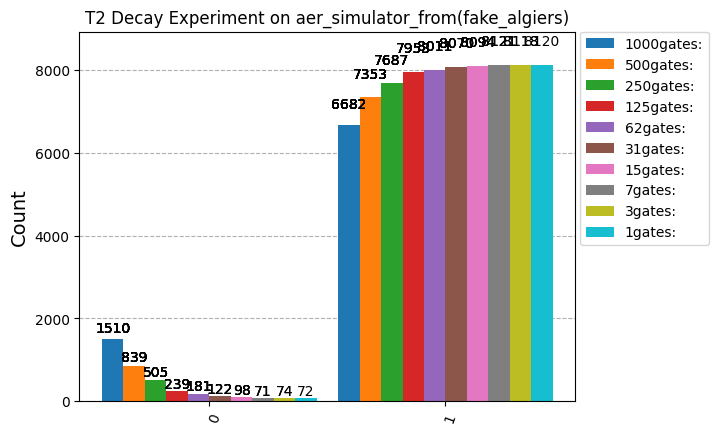

In [22]:
if __name__ == '__main__':
    main()